In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from brain_image.configs import get_device
from brain_image.model import NICEModel


In [3]:
import logging
from dalle2_pytorch import DiffusionPrior
from dalle2_pytorch.dalle2_pytorch import CausalTransformer, SinusoidalPosEmb, MLP
import torch
import torch.nn as nn
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
from torch.nn import functional as F


class DiffusionPriorNetwork(nn.Module):
    # Adapted from https://github.com/lucidrains/DALLE2-pytorch/blob/main/dalle2_pytorch/dalle2_pytorch.py

    def __init__(
        self,
        dim,
        num_timesteps: int | None = None,
        num_time_embeds: int = 1,
        num_image_embeds: int = 1,
        num_text_embeds: int = 1,
        max_text_len: int = 256,
        self_cond: bool = False,
        num_output_tokens: int = 256,
        **kwargs,
    ):
        super().__init__()
        self.dim = dim

        self.num_time_embeds = num_time_embeds
        self.num_image_embeds = num_image_embeds
        self.num_text_embeds = num_text_embeds

        self.to_text_embeds = nn.Sequential(
            (
                nn.Linear(dim, dim * num_text_embeds)
                if num_text_embeds > 1
                else nn.Identity()
            ),
            Rearrange("b (n d) -> b n d", n=num_text_embeds),
        )

        self.continuous_embedded_time = num_timesteps is None

        self.to_time_embeds = nn.Sequential(
            (
                nn.Embedding(num_timesteps, dim * num_time_embeds)
                if num_timesteps is not None
                else nn.Sequential(
                    SinusoidalPosEmb(dim), MLP(dim, dim * num_time_embeds)
                )
            ),  # also offer a continuous version of timestep embeddings, with a 2 layer MLP
            Rearrange("b (n d) -> b n d", n=num_time_embeds),
        )

        self.to_image_embeds = nn.Sequential(
            (
                nn.Linear(dim, dim * num_image_embeds)
                if num_image_embeds > 1
                else nn.Identity()
            ),
            Rearrange("b (n d) -> b n d", n=num_image_embeds),
        )

        self.learned_query = nn.Parameter(torch.randn(dim))
        self.causal_transformer = CausalTransformer(dim=dim, **kwargs)

        # dalle1 learned padding strategy

        self.max_text_len = max_text_len

        self.null_text_encodings = nn.Parameter(torch.randn(1, max_text_len, dim))
        self.null_text_embeds = nn.Parameter(torch.randn(1, num_text_embeds, dim))
        self.null_image_embed = nn.Parameter(torch.randn(1, dim))

        # whether to use self conditioning, Hinton's group's new ddpm technique

        self.self_cond = self_cond

        # Number of output tokens
        self.num_output_tokens = num_output_tokens

    def forward_with_cond_scale(self, *args, cond_scale=1.0, **kwargs):
        logits = self.forward(*args, **kwargs)

        if cond_scale == 1:
            return logits

        null_logits = self.forward(
            *args, text_cond_drop_prob=1.0, image_cond_drop_prob=1, **kwargs
        )
        return null_logits + (logits - null_logits) * cond_scale

    def _cond_drop_prob(self, prob: float, batch: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
        if prob == 0.0:
            p = torch.ones((batch,), device=device, dtype=dtype)
        elif prob == 1.0:
            p = torch.zeros((batch,), device=device, dtype=dtype)
        else:
            p = torch.rand((batch,), device=device, dtype=dtype) < 1 - prob
        return p.bool()

    def forward(
        self,
        image_embed,
        diffusion_timesteps,
        *,
        text_embed,
        text_encodings=None,
        self_cond=None,
        text_cond_drop_prob=0.0,
        image_cond_drop_prob=0.0,
    ):
        batch, dim, device, dtype = (
            *image_embed.shape,
            image_embed.device,
            image_embed.dtype,
        )

        # setup self conditioning

        if self.self_cond:
            self_cond = self_cond or torch.zeros(batch, self.dim, device=device, dtype=dtype)
            self_cond = rearrange(self_cond, "b d -> b 1 d")

        # in section 2.2, last paragraph
        # "... consisting of encoded text, CLIP text embedding, diffusion timestep embedding, noised CLIP image embedding, final embedding for prediction"

        text_embed = self.to_text_embeds(text_embed)
        image_embed = self.to_image_embeds(image_embed)

        # classifier free guidance masks
        text_keep_mask = self._cond_drop_prob(text_cond_drop_prob, batch, device, dtype)
        text_keep_mask = rearrange(text_keep_mask, "b -> b 1 1")

        image_keep_mask = self._cond_drop_prob(image_cond_drop_prob, batch, device, dtype)
        image_keep_mask = rearrange(image_keep_mask, "b -> b 1 1")

        # make text encodings optional
        # although the paper seems to suggest it is present <--

        if text_encodings is None:
            text_encodings = torch.empty((batch, 0, dim), device=device, dtype=dtype)

        mask = torch.any(text_encodings != 0.0, dim=-1)

        # replace any padding in the text encodings with learned padding tokens unique across position

        text_encodings = text_encodings[:, : self.max_text_len]
        mask = mask[:, : self.max_text_len]

        text_len = text_encodings.shape[-2]
        remainder = self.max_text_len - text_len

        if remainder > 0:
            text_encodings = F.pad(text_encodings, (0, 0, 0, remainder), value=0.0)
            mask = F.pad(mask, (0, remainder), value=False)

        # mask out text encodings with null encodings

        null_text_encodings = self.null_text_encodings.to(text_encodings.dtype)

        text_encodings = torch.where(
            rearrange(mask, "b n -> b n 1").clone() & text_keep_mask,
            text_encodings,
            null_text_encodings,
        )

        # mask out text embeddings with null text embeddings

        null_text_embeds = self.null_text_embeds.to(text_embed.dtype)

        text_embed = torch.where(text_keep_mask, text_embed, null_text_embeds)

        # mask out image embeddings with null image embeddings

        null_image_embed = self.null_image_embed.to(image_embed.dtype)

        image_embed = torch.where(image_keep_mask, image_embed, null_image_embed)

        # whether text embedding is used for conditioning depends on whether text encodings are available for attention (for classifier free guidance, even though it seems from the paper it was not used in the prior ddpm, as the objective is different)
        # but let's just do it right

        if self.continuous_embedded_time:
            diffusion_timesteps = diffusion_timesteps.type(dtype)

        time_embed = self.to_time_embeds(diffusion_timesteps)

        learned_queries = repeat(self.learned_query, "d -> b 1 d", b=batch)

        if self.self_cond:
            learned_queries = torch.cat((self_cond, learned_queries), dim=-2)

        tokens = torch.cat(
            (text_encodings, text_embed, time_embed, image_embed, learned_queries),
            dim=-2,
        )

        # attend

        tokens = self.causal_transformer(tokens)

        # get learned query, which should predict the image embedding (per DDPM timestep)

        pred_image_embed = tokens[..., -1, :]

        return pred_image_embed
    

logging.basicConfig(level=logging.INFO)

cp_path = "logs/nice/version_38/checkpoints/nice-epoch=24-val_top1_acc=0.3790.ckpt"
nice_model = NICEModel.load_checkpoint(cp_path, compile=False)
device = get_device()

print(nice_model.config.project_dim)

net = DiffusionPriorNetwork(
    dim=nice_model.config.project_dim,
    num_timesteps=1000,
    num_time_embeds=1,
    num_image_embeds=1,
    num_text_embeds=1,
    max_text_len=nice_model.config.project_dim,
    self_cond=False,
    num_output_tokens=nice_model.config.project_dim,
    depth=6,
)
net.to(device)

prior = DiffusionPrior(
    net=net,
    image_embed_dim=nice_model.config.project_dim,
    condition_on_text_encodings=False
)

prior.eval()

prior.to(device)

768


DiffusionPrior(
  (noise_scheduler): NoiseScheduler()
  (net): DiffusionPriorNetwork(
    (to_text_embeds): Sequential(
      (0): Identity()
      (1): Rearrange('b (n d) -> b n d', n=1)
    )
    (to_time_embeds): Sequential(
      (0): Embedding(1000, 768)
      (1): Rearrange('b (n d) -> b n d', n=1)
    )
    (to_image_embeds): Sequential(
      (0): Identity()
      (1): Rearrange('b (n d) -> b n d', n=1)
    )
    (causal_transformer): CausalTransformer(
      (init_norm): Identity()
      (rel_pos_bias): RelPosBias(
        (relative_attention_bias): Embedding(32, 8)
      )
      (layers): ModuleList(
        (0-5): 6 x ModuleList(
          (0): Attention(
            (norm): LayerNorm()
            (dropout): Dropout(p=0.0, inplace=False)
            (to_q): Linear(in_features=768, out_features=512, bias=False)
            (to_kv): Linear(in_features=768, out_features=128, bias=False)
            (rotary_emb): RotaryEmbedding()
            (to_out): Sequential(
             

In [4]:
# Setup temp example

import os
os.environ["TORCHDYNAMO_VERBOSE"] = "1"

In [5]:
# First we project

# First, we will open an image latent and decode that to the proper image.

loader = nice_model.data_module.test_dataloader()
ex_batch = next(iter(loader))
img_latent = ex_batch["img_latent"]
eeg_data = ex_batch["eeg_data"]
img_path = ex_batch["img_path"]

with torch.no_grad():

    # Normalize
    img_latent = img_latent / nn.functional.normalize(img_latent, dim=-1)
    img_latent = img_latent.to(device)

    print(img_latent.shape)

    # Brain embed
    eeg_embed = nice_model.eeg_encoder(eeg_data)
    eeg_proj = nice_model.eeg_projector(eeg_embed).to(device)

    print(eeg_proj.shape)

    prior.forward(text_embed=eeg_proj, image_embed=img_latent)

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


torch.Size([256, 768])
torch.Size([256, 768])


In [6]:
del prior
del net
torch.cuda.empty_cache()

In [7]:
import os
import dotenv

dotenv.load_dotenv()

tok = os.environ.get("HF_API_TOKEN")
if not tok:
    raise ValueError("HF_API_TOKEN is not set")

from huggingface_hub import login
login(token=tok)

In [12]:
import diffusers
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline, StableDiffusion3Img2ImgPipeline, StableDiffusionXLImg2ImgPipeline
import torch


# We're going to do the following:
# Load stable diffusion 2.1
# Take the VAE and use it to encode the raw image to latent space
# Use this raw latent as target for the diffusion model (Using EEG Proj as conditioning)

diffusion_model = StableDiffusionImg2ImgPipeline.from_pretrained(
    #"sd-legacy/stable-diffusion-v1-5",
    "stabilityai/stable-diffusion-2-1",
    #"stabilityai/stable-diffusion-3.5-large",
    #"stabilityai/stable-diffusion-xl-refiner-1.0",
    #"stabilityai/stable-diffusion-xl-base-1.0",
    #torch_dtype=torch.float16,
   # variant="fp16",
    #local_files_only=False,

    text_encoder=None,
    tokenizer=None,
    text_encoder_2=None,
    tokenizer_2=None,
    variant="fp16",
    torch_dtype=torch.float16,
).to("cuda")





model_index.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/1.73G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/345 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/939 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

Keyword arguments {'text_encoder_2': None, 'tokenizer_2': None} are not expected by StableDiffusionImg2ImgPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
LOAD_IP_ADAPTER = True
USING_XL = True

if LOAD_IP_ADAPTER:
  # https://huggingface.co/docs/diffusers/main/en/using-diffusers/ip_adapter?usage=image-to-image

  diffusion_model.load_ip_adapter(
    #"h94/IP-Adapter",
    #subfolder="models",
    #subfolder="sdxl_models",
    #weight_name="ip-adapter_sd15.bin",
    #weight_name="ip-adapter_sdxl.bin",
    #"InstantX/SD3.5-Large-IP-Adapter",
    #subfolder=None,
    #weight_name="ip-adapter.bin",
    #local_files_only=False,
    #variant="fp16",
    #torch_dtype=torch.float16,
  )
  diffusion_model.set_ip_adapter_scale(1.0)

TypeError: argument should be a str or an os.PathLike object where __fspath__ returns a str, not 'NoneType'

In [ ]:
vae = diffusion_model.vae


vae.eval()
vae.to("cuda")

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

In [ ]:
from pathlib import Path
from brain_image.data import load_image_from_path, preprocess_image


images = torch.stack([load_image_from_path(Path(p)) for p in img_path])[:4]
print("Images loaded", images.shape)


pp_img = preprocess_image(images)
print("Images preprocessed", pp_img.shape)

Images loaded torch.Size([4, 3, 500, 500])
Images preprocessed torch.Size([4, 3, 224, 224])


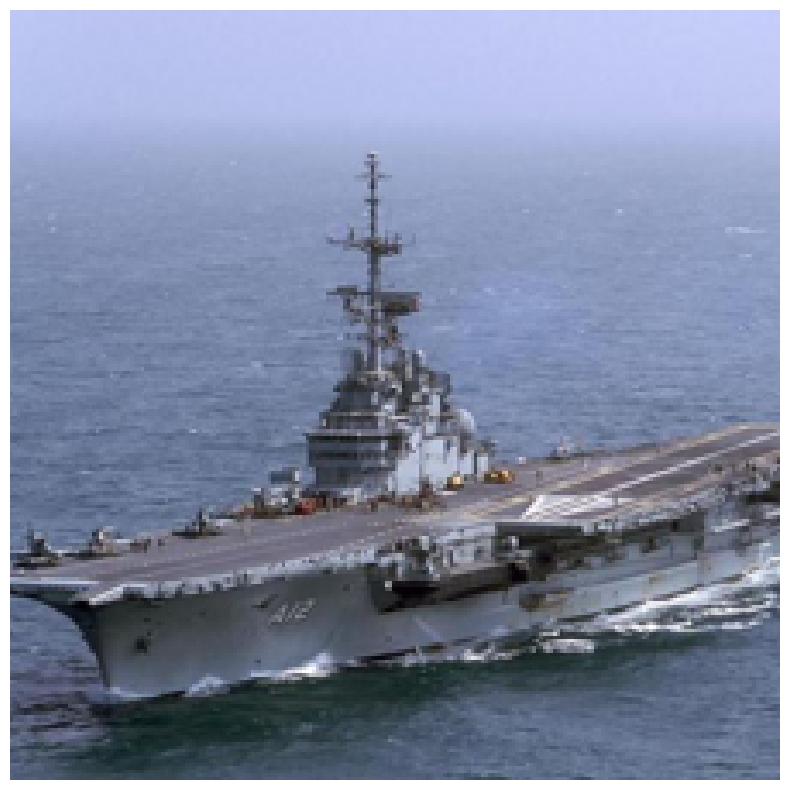

tensor(255.) tensor(0.)
tensor(1.) tensor(0.)


In [ ]:

import matplotlib.pyplot as plt

def show_image(*imgs):
    imgs = [img.detach().cpu().float() for img in imgs]
    merged_imgs = []
    for img in imgs:
        if len(img.shape) == 3:
            merged_imgs.append(img)
        elif len(img.shape) == 4:
            for i in range(img.shape[0]):
                merged_imgs.append(img[i])
        else:
            raise ValueError(f"Invalid image shape: {img.shape}")
    imgs = merged_imgs

    fig, axs = plt.subplots(1, len(imgs), figsize=(10*len(imgs), 10))
    if len(imgs) == 1:
        axs = [axs]
    
    for i, img in enumerate(imgs):
        img = img.detach().cpu().float()
        
        if img.shape[-1] != 3:
            if len(img.shape) == 3:
                img = img.permute(1, 2, 0)
            else:
                img = img.permute(0, 2, 3, 1)
        axs[i].imshow(img)
        axs[i].axis("off")
    plt.show()

show_image(pp_img[0])
print(images.max(), images.min())
print((images / 255.0).max(), (images / 255.0).min())

In [ ]:
torch.cuda.empty_cache()

torch.Size([1, 3, 224, 224]) torch.Size([1, 4, 28, 28]) torch.Size([1, 3, 224, 224])


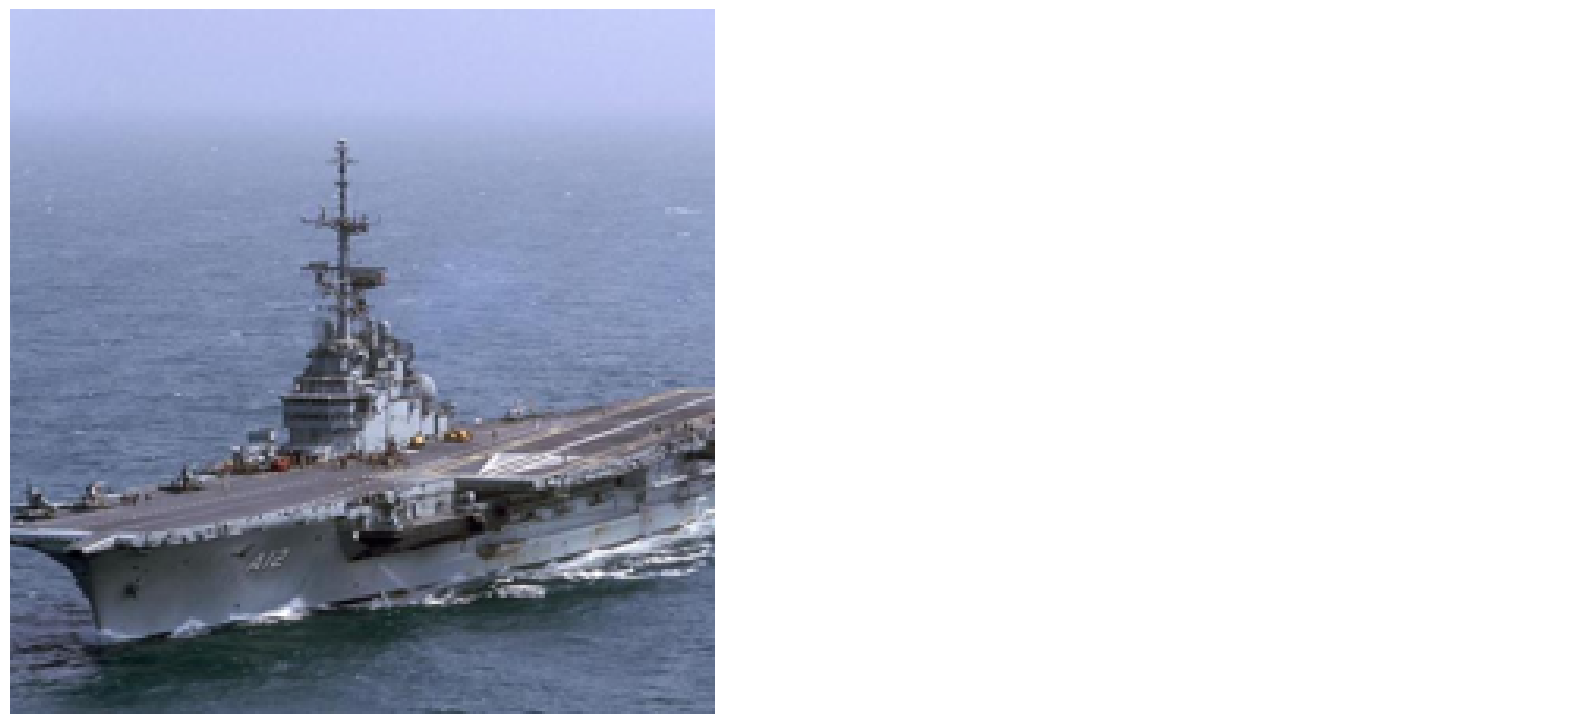

In [ ]:
with torch.no_grad():
    x = pp_img[:1].to(dtype=torch.float16, device=device)
    z = vae.encode(x).latent_dist.mode()
    xd = vae.decode(z).sample
    print(x.shape, z.shape, xd.shape)

show_image(x, xd[0].detach().cpu().float())

In [ ]:
print(pp_img.shape)

torch.Size([4, 3, 224, 224])


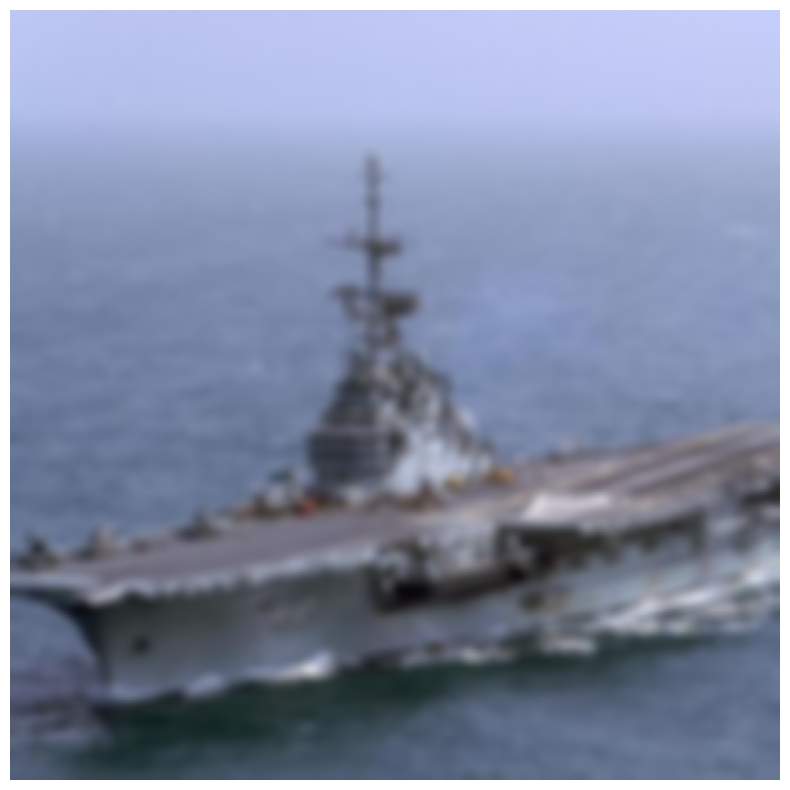

In [ ]:
# We create an artificially terrible image for guidance

from torchvision.transforms.v2 import GaussianBlur,Compose, RandomPerspective, Resize

original_images = pp_img[:1]

# Add 

# Apply the noise to the image

noise_pipe = Compose([
    GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0)),
    #RandomPerspective(distortion_scale=0.1, p=0.5), 
    Resize((500, 500))
])

noisy_images = noise_pipe(original_images)

# Apply the denoising process

show_image(noisy_images[0])


  0%|          | 0/50 [00:00<?, ?it/s]

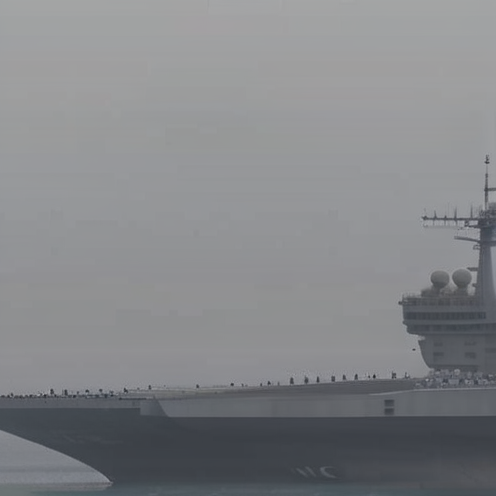

In [ ]:
# First we use IP adapter to embed image
from diffusers.utils import load_image


kwargs = {
    "image": noisy_images[:1],
    #"prompt": "uboat, high quality, 8k, super mega uboat",
    "prompt": "",
    "strength": 1.0,
    #"guidance_scale":7.5,
    #"num_inference_steps":50
}
if LOAD_IP_ADAPTER:
    #ip_img = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_adapter_diner.png")
    ip_img = pp_img[:1]
    kwargs["ip_adapter_image"] = ip_img

outs = diffusion_model(
    **kwargs
).images


outs[0]


